## HW 2: Crossentropy method
_Reference: based on Practical RL course by YSDA_

In this notebook you have to solve two simple RL problems with crossentropy method.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to file `template_crossentropy.py` and submit it to the Contest.


## ДЗ 2: Метод кроссэнтропии
Основано на практическом курсе RL от YSDA_

В этом ноутбуке вам предстоит решить две простые задачи по RL методом кроссэнтропии.

Чтобы ознакомиться с пакетом "gymnasium", пожалуйста, ознакомьтесь с [документацией](https://gymnasium.farama.org/introduction/basic_usage/).


В конце блокнота, пожалуйста, скопируйте реализованные вами функции в файл `template_crossentropy.py" и отправьте его в контекст.

In [30]:
!pip install gymnasium

In [31]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import pandas as pd
%matplotlib inline

**gymnasium** — популярная библиотека Python, разработанная для исследований и разработки в области обучения с подкреплением (Reinforcement Learning, RL). Она предоставляет стандартизированные среды (environments), в которых агенты (алгоритмы RL) могут взаимодействовать с окружением, обучаться и тестироваться.  

gymnasium включает множество предопределённых сред (например, классические задачи управления, игры Atari, робототехнические симуляции), где агент должен выполнять задачи:

* `CartPole`: балансирование шеста на тележке
* `MountainCar`: движение автомобиля в гору
* `Atari Games`: такие как Pong, Space Invaders
* `MuJoCo`: физическое моделирование для роботов


Все среды имеют одинаковый API-интерфейс, что упрощает тестирование алгоритмов:

* `reset()`: сброс среды в начальное состояние
* `step(action)`: выполнение действия и получение нового состояния, награды и флага завершения
* `render()`: визуализация процесса (если supported)

## Part 1. Tabular CrossEntropy
Let's consider discrete game "Taxi".

There are four designated pick-up and drop-off locations (Red, Green, Yellow and Blue) in the 5x5 grid world. The taxi starts off at a random square and the passenger at one of the designated locations.

The goal is move the taxi to the passenger’s location, pick up the passenger, move to the passenger’s desired destination, and drop off the passenger. Once the passenger is dropped off, the episode ends.

The player receives positive rewards for successfully dropping-off the passenger at the correct location. Negative rewards for incorrect attempts to pick-up/drop-off passenger and for each step where another reward is not received.

You can find full description of the environment [here](https://gymnasium.farama.org/environments/toy_text/taxi/).

![Taxi-v3](https://gymnasium.farama.org/_images/taxi.gif)

So here's how it works:

## Часть 1. Табличная кроссэнтропия
Давайте рассмотрим дискретную игру "Такси".

В мире с сеткой 5х5 есть четыре специально отведенных места для посадки и высадки пассажиров (красное, зеленое, желтое и синее). Такси отправляется в случайном месте, а пассажир - в одном из обозначенных мест.

Цель состоит в том, чтобы доставить такси к месту, где находится пассажир, забрать пассажира, доехать до нужного пункта назначения и высадить пассажира. Как только пассажир высажен, эпизод заканчивается.

Игрок получает положительные награды за успешную высадку пассажира в нужном месте. Отрицательные награды за неправильные попытки посадки/высадки пассажира и за каждый шаг, за который не была получена другая награда.

Вы можете найти полное описание обстановки [здесь](https://gymnasium.farama.org/environments/toy_text/taxi/).

![Taxi-v3](https://gymnasium.farama.org/_images/taxi.gif)

Итак, вот как это работает:

In [32]:
pip install "gymnasium[toy-text]"

Note: you may need to restart the kernel to use updated packages.


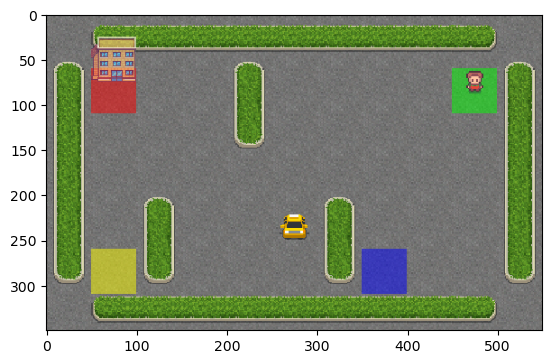

In [33]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
env.reset()

plt.imshow(env.render())

Этот код создаёт и визуализирует среду "Taxi-v3" из библиотеки Gymnasium.  

- `env = gym.make("Taxi-v3", render_mode="rgb_array")`
Создание среды: Создаётся объект среды `"Taxi-v3"` — это известная задача из обучения с подкреплением, где такси должно подобрать пассажира и отвезти его в нужное место.
Параметр `render_mode="rgb_array"`: Указывает, что рендеринг среды должен возвращать изображение в виде массива NumPy (в формате RGB), а не отображать его в отдельном окне.

- `env.reset()`
Сброс среды: Возвращает среду в начальное состояние. Это стандартная процедура перед началом взаимодействия со средой.
Возвращаемое значение: Обычно reset() возвращает начальное состояние (наблюдение) и дополнительную информацию, но в данном коде возвращаемые значения не присваиваются переменным.

- `plt.imshow(env.render())`
Рендеринг состояния: `env.render()` генерирует визуальное представление текущего состояния среды **в виде массива пикселей** (формат RGB).
Отображение изображения: `plt.imshow()` из библиотеки Matplotlib **принимает этот массив и отображает его как изображение**

*Рендеринг (от англ. rendering — «визуализация») — процесс преобразования трёхмерной модели в двухмерное изображение с помощью компьютерных программ. 

In [34]:
env.close()

**Закрытие среды**: Этот метод освобождает ресурсы, связанные со средой (например, графические окна, процессы и т.д.). Это хорошая практика **для избежания утечек памяти**, особенно когда вы закончили работать со средой.

In [35]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print("n_states=%i, n_actions=%i" % (n_states, n_actions))

n_states=500, n_actions=6


`n_states = env.observation_space.n` – получение количества состояний:

* `env.observation_space` описывает **пространство возможных состояний среды**
* `.n` возвращает **количество дискретных состояний в среде**

Для "Taxi-v3" это значение равно 500


`n_actions = env.action_space.n` – получение количества действий

* `env.action_space` описывает пространство возможных действий
* `.n` возвращает количество дискретных действий, которые может предпринять агент
Для "Taxi-v3" это значение равно 6


`print("n_states=%i, n_actions=%i" % (n_states, n_actions))` – выводит полученные значения в заданном формате


**Что означают эти числа для среды "Taxi-v3"?**

500 состояний:
**Среда "Taxi-v3" имеет 500 возможных состояний, которые представляют комбинации:**

- Положение такси на сетке 5×5 (25 позиций)
- Положение пассажира (5 возможностей: 4 точки посадки + в такси)
- Положение пункта назначения (4 возможных точки высадки)
- Расчёт: 25 (позиций такси) × 5 (положений пассажира) × 4 (пункта назначения) = 500

6 действий:
**Агент (такси) может выполнять 6 различных действий:**

1. Движение на юг (вниз)
2. Движение на север (вверх)
3. Движение на восток (вправо)
4. Движение на запад (влево)
5. Посадка пассажира
6. Высадка пассажира


**Зачем это нужно?**

Эта информация важна для разработки алгоритмов обучения с подкреплением:
- Определяет размерность Q-таблицы для табличных методов (например, Q-learning)  
- Помогает проектировать архитектуру нейронных сетей для методов глубокого обучения с подкреплением  
- Позволяет понять сложность решаемой задачи  
- После получения этой информации обычно следует процесс обучения агента, где он учится выбирать оптимальные действия в каждом состоянии для максимизации награды  

Выполним действие 1 и посмотрим, что получится:

In [36]:
next_state, reward, is_done, _, _ = env.step(1)

Выполнение действия: `env.step(1)` выполняет действие с номером 1 в текущем состоянии среды.
Распаковка результатов: Метод `step()` возвращает кортеж из 5 значений:

- `next_state`: новое состояние среды после выполнения действия
- `reward`: награда, полученная за выполнение действия
- `is_done`: флаг завершения эпизода (True/False)
- `truncated`: флаг обрезания эпизода (игнорируется с помощью _)
- `info`: дополнительная информация (игнорируется с помощью _)  



Действие 1 в среде "Taxi-v3"

В этой среде действия кодируются числами от 0 до 5:

0: движение на юг (вниз)
1: движение на север (вверх) ← это действие выполняется в данном коде
2: движение на восток (вправо)
3: движение на запад (влево)
4: посадка пассажира
5: высадка пассажира


**Что может произойти в зависимости от ситуации:**

**Успешное движение:**
- Если такси может двигаться вверх (нет стены)
- `next_state`: новое положение такси
- `reward`: обычно -1 (штраф за каждый шаг)
- `is_done`: False (игра продолжается)

**Попытка движения в стену:**
Если такси пытается выйти за границы карты
- `next_state`: остаётся в том же состоянии
- `reward`: обычно -1 (штраф за бесполезное действие)
- `is_done`: False

**Успешная посадка/высадка:**
Если действие соответствует правильной посадке или высадке
- `reward`: положительная награда (обычно +10 или +20)
- `is_done`: может стать True, если пассажир доставлен

**Неправильная посадка/высадка:**
Если действие выполнено в неправильном месте
- `reward`: отрицательная награда (обычно -10)

In [37]:
print(f"We got to state {next_state}, the reward is {reward}, game is not finished because is_done={is_done}")

We got to state 244, the reward is -1, game is not finished because is_done=False


Код выводит информацию о результате выполнения действия. Это означает, что:
- Такси переместилось в состояние 44
- Получена награда -1 (штраф за шаг)
- Эпизод не завершён (игра продолжается)

### Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize policy __uniformly__, that is, probabililities of all actions should be equal.


Создайте стохастическую политику  
  
На этот раз нашей политикой должно быть распределение вероятностей  
```policy[s,a] = P(выполнение действия a | в состоянии  s)```  
  
Поскольку мы по-прежнему используем целочисленные представления состояния и действия, вы можете использовать двумерный массив для представления политики  
  
Пожалуйста, **инициализируйте политику единообразно**, то есть **вероятности всех действий должны быть равны**  

In [38]:
policy = np.ones((n_states, n_actions)) / n_actions

- Цель: Создать матрицу политики, где `policy[s, a] = P(выполнить действие a | в состоянии s)`  
- Размерность: **Матрица размером n_states × n_actions (500×6 для Taxi-v3)**  

Инициализация:
`np.ones((n_states, n_actions))` **создаёт матрицу, заполненную единицами**. 
**Деление на n_actions (6) гарантирует, что сумма вероятностей по всем действиям в каждом состоянии равна 1**

In [39]:
assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1./n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

- Первая проверка: Убеждается, что **policy является numpy-массивом или матрицей**  
- Вторая проверка: Проверяет, что **все элементы policy равны 1/n_actions (≈0.1667)**  
- Третья проверка: Проверяет, что **сумма вероятностей по всем действиям в каждом состоянии равна 1**

In [40]:
policy

array([[0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       ...,
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667],
       [0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667]])

### Play the game

Just like before, but we also record all states and actions we took.

Sample the action (e.g. `np.random.choice()`) from available actions and make a step in the environment using `env.step()`.


### Проиграйте в игру

Как и раньше, но мы также записываем все состояния и действия, которые мы выполняли.

Выберите действие (например, `np.random.choice()`) из доступных действий и выполните шаг в среде, используя `env.step()`.

In [41]:
def generate_session(env, policy, t_max=int(10**4)):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.

    s, info = env.reset()

    for t in range(t_max):
        # Sample action from policy for current state
        a = np.random.choice(n_actions, p=policy[s])
        
        # Take the action in the environment
        new_s, r, done, truncated, info = env.step(a)
        
        # Verify that we got valid values
        assert new_s is not None and r is not None and done is not None
        assert a is not None
        # your code here
        # Record state, action and add up reward to states,actions and total_reward accordingly.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break
    return states, actions, total_reward

1. Выбор действия:
`a = np.random.choice(n_actions, p=policy[s])`
- `np.random.choice` случайным образом выбирает действие из всех возможных действий (0 до 5)
- Параметр `p=policy[s]` указывает вероятности выбора каждого действия в текущем состоянии s  
Это реализует стохастическую политику, где действия выбираются согласно распределению вероятностей

2. Выполнение действия в среде:
`new_s, r, done, truncated, info = env.step(a)`  
Выполняет выбранное действие a в среде  
Возвращает новое состояние `new_s`, награду `r`, флаги завершения `done` и `truncated`, и дополнительную информацию `info`

3. Запись данных:
- `states.append(s)` - сохраняет текущее состояние
- `actions.append(a)` - сохраняет выполненное действие
- `total_reward += r` - суммирует полученные награды

4. Обновление состояния и проверка завершения:
- `s = new_s` - переходит в новое состояние для следующей итерации
- `if done: break` - прерывает цикл, если эпизод завершён  
Этот код позволяет генерировать сессии (траектории) взаимодействия агента со средой, используя заданную стохастическую политику. Полученные данные (состояния, действия, награды) затем могут быть использованы для обучения политики, например, с помощью алгоритмов политического градиента.

In [42]:
s, a, r = generate_session(env=env, policy=policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

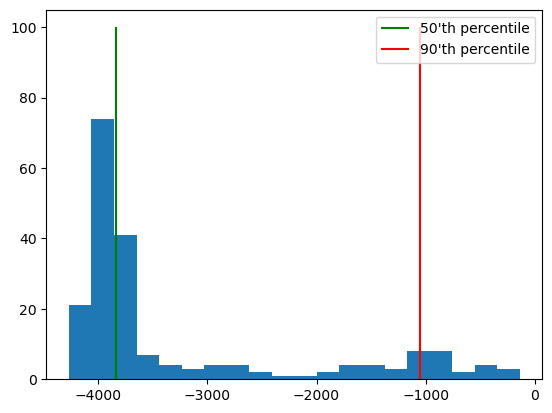

In [43]:
# let's see the initial reward distribution
import matplotlib.pyplot as plt
%matplotlib inline

sample_rewards = [generate_session(env=env, policy=policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()

In [44]:
np.percentile(sample_rewards, 50)

-3835.0

Это очень плохой результат для среды Taxi-v3.

**Что означает значение -3835.0?**
- В среде Taxi-v3 каждый шаг наказывается наградой -1
- Значение -3835 означает, что в среднем агенту потребовалось около 3835 шагов, чтобы завершить задачу (или достичь лимита в 1000 шагов с множеством штрафов)
- Для сравнения: оптимальное решение в Taxi-v3 обычно требует менее 20 шагов

**Как интерпретировать процентили?**
- 50-й процентиль (медиана) = -3835: Половина сессий показала результат хуже -3835, половина - лучше
- 90-й процентиль: Только 10% сессий показали результат лучше этого значения

**Какой результат считается хорошим?**

Цели в среде Taxi-v3:
- Успешная доставка пассажира: +20 награды
- Минимизация количества шагов: Каждый шаг дает -1

Хорошие результаты:
- От 0 до +15: Агент успешно доставляет пассажира с небольшим количеством шагов
- Оптимальное решение: Обычно дает награду около +10 до +15 (20 за доставку минус 5-10 шагов)

Этапы улучшения:
1. Случайная политика (текущее состояние): -3000 до -4000
2. Начальное обучение: -100 до -500
3. Умеренное обучение: -50 до 0
4. Хорошее обучение: +5 до +15
5. Оптимальное решение: +10 до +15

**Почему такой плохой результат?**
При равномерной случайной политике:
- Агент с очень низкой вероятностью совершает правильные действия
- Часто пытается подобрать/высадить пассажира не в том месте (штраф -10)
- Совершает много бесполезных движений (штраф -1 за шаг)

### Crossentropy method steps

In [45]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    """
    # Calculate threshold reward for the given percentile
    threshold = np.percentile(rewards_batch, percentile)
    
    # Initialize lists for elite states and actions
    elite_states = []
    elite_actions = []
    
    # Iterate through all sessions
    for i in range(len(rewards_batch)):
        # Check if session reward meets or exceeds the threshold
        if rewards_batch[i] >= threshold:
            # Add all states and actions from this elite session
            elite_states.extend(states_batch[i])
            
            # Convert tensor actions to integers if needed
            if isinstance(actions_batch[i][0], torch.Tensor):
                elite_actions.extend([a.item() for a in actions_batch[i]])
            else:
                elite_actions.extend(actions_batch[i])
    
    return elite_states, elite_actions

In [46]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=0)
test_result_40 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30)
test_result_90 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=90)
test_result_100 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=100)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1])  \
    and np.all(test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]),\
    "For percentile 0 you should return all states and actions in chronological order"
assert np.all(test_result_40[0] == [4, 2, 0, 2, 3, 1]) and \
    np.all(test_result_40[1] == [3, 2, 0, 1, 3, 3]),\
    "For percentile 30 you should only select states/actions from two first"
assert np.all(test_result_90[0] == [3, 1]) and \
    np.all(test_result_90[1] == [3, 3]),\
    "For percentile 90 you should only select states/actions from one game"
assert np.all(test_result_100[0] == [3, 1]) and\
    np.all(test_result_100[1] == [3, 3]),\
    "Please make sure you use >=, not >. Also double-check how you compute percentile."
print("Ok!")

Ok!


In [47]:
def update_policy(elite_states, elite_actions, n_states=n_states, n_actions=n_actions):
    """
    Given old policy and a list of elite states/actions from select_elites,
    return new updated policy where each action probability is proportional to

    policy[s_i,a_i] ~ #[occurences of si and ai in elite states/actions]

    Don't forget to normalize policy to get valid probabilities and handle 0/0 case.
    In case you never visited a state, set probabilities for all actions to 1./n_actions

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions
    :param n_states: number of states in the environment
    :param n_actions: number of actions in the environment

    :returns: new_policy: np.array of shape (n_states, n_actions)
    """
    # Initialize new policy with zeros
    new_policy = np.zeros((n_states, n_actions))
    
    # Count occurrences of each state-action pair in elite data
    for state, action in zip(elite_states, elite_actions):
        new_policy[state, action] += 1
    
    # Normalize each row to get probabilities
    row_sums = new_policy.sum(axis=1, keepdims=True)
    
    # Handle states that were never visited (row_sum = 0)
    # Set them to uniform distribution
    new_policy[row_sums.flatten() == 0] = 1.0 / n_actions
    
    # Recalculate row sums after handling unvisited states
    row_sums = new_policy.sum(axis=1, keepdims=True)
    
    # Normalize all rows
    new_policy /= row_sums
    
    # Verify that all rows sum to 1 (within floating point precision)
    assert np.allclose(new_policy.sum(axis=1), 1), "Policy rows should sum to 1"
    
    return new_policy

In [48]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = update_policy(elite_states, elite_actions)

assert np.isfinite(new_policy).all(
), "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(
    new_policy >= 0), "Your new policy can't have negative action probabilities"
assert np.allclose(new_policy.sum(
    axis=-1), 1), "Your new policy should be a valid probability distribution over actions"
reference_answer = np.array([
    [1.,  0.,  0.,  0.,  0.],
    [0.5,  0.,  0.,  0.5,  0.],
    [0.,  0.33333333,  0.66666667,  0.,  0.],
    [0.,  0.,  0.,  0.5,  0.5]])
assert np.allclose(new_policy[:4, :5], reference_answer)
print("Ok!")

Ok!


### Training loop
Generate sessions, select N best and fit to those.

In [49]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label='Mean rewards')
    plt.plot(list(zip(*log))[1], label='Reward thresholds')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines([np.percentile(rewards_batch, percentile)],
               [0], [100], label="percentile", color='red')
    plt.legend()
    plt.grid()

    plt.show()

In [50]:
# reset policy just in case
policy = np.ones([n_states, n_actions]) / n_actions

mean reward = -40.056, threshold=-31.500


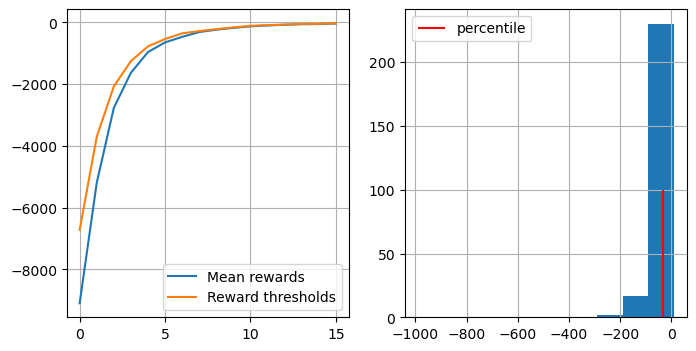

You Win!


In [51]:
n_sessions = 250  # sample this many sessions
percentile = 50  # take this percent of session with highest rewards
learning_rate = 0.5  # add this thing to all counts for stability

log = []

for i in range(100):

    %time sessions = [generate_session(env, policy) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    new_policy = update_policy(elite_states, elite_actions)

    policy = learning_rate*new_policy + (1-learning_rate)*policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)
    if np.mean(rewards_batch) > -50:
        print("You Win!")
        break

Congratulations! You've just trained your first RL model!
Now copy functions from this notebook to `template_crossentropy.py` and submit it to the Contest problem `Tabular CrossEntropy`.

## Part 2: Approximate crossentropy and neural nets.

In this section you will train a neural network policy for continuous state space game

You can find full description of the environment [here](https://www.gymlibrary.dev/environments/classic_control/cart_pole/).

![CartPole-v0"](https://www.gymlibrary.dev/_images/cart_pole.gif)

So here's how it works:

In [52]:
# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n

/Users/SSkobeleva/anaconda3/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


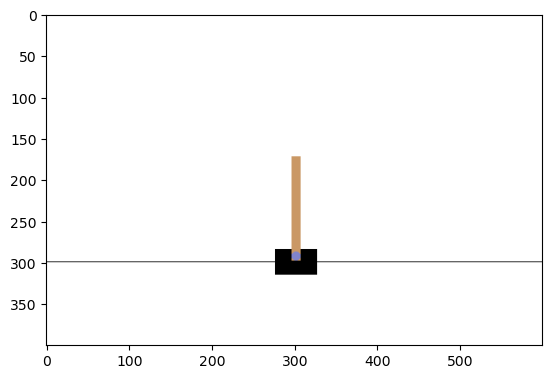

In [53]:
plt.imshow(env.render())

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim

class PolicyNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Определите размерности
state_size = env.observation_space.shape[0]
n_actions = env.action_space.n
hidden_size = 24

# Инициализируйте агента
agent = PolicyNetwork(state_size, hidden_size, n_actions)
optimizer = optim.Adam(agent.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [55]:
def generate_session_cartpole(t_max=300):
    states, actions = [], []
    total_reward = 0

    s, info = env.reset()

    for t in range(t_max):
        # Sample action from policy for current state
        state_tensor = torch.FloatTensor(s).unsqueeze(0)
        with torch.no_grad():
            action_logits = agent(state_tensor)
            action_probs = torch.softmax(action_logits, dim=1).numpy()[0]
        
        a = np.random.choice(n_actions, p=action_probs)
        # Convert action to tensor
        a_tensor = torch.tensor(a)

        new_s, r, done, truncated, info = env.step(a)

        # Record session data
        states.append(s)
        actions.append(a_tensor)  # Store as tensor
        total_reward += r

        s = new_s
        if done:
            break
            
    return states, actions, total_reward

mean reward = 217.670, threshold=300.000


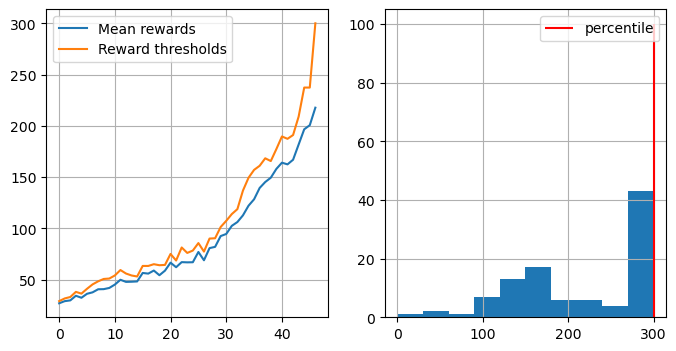

You Win!


In [56]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # Генерируем новые сессии
    sessions = [generate_session_cartpole() for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    
    # Преобразуем данные в тензоры PyTorch
    elite_states_tensor = torch.FloatTensor(np.vstack(elite_states))
    elite_actions_tensor = torch.LongTensor(np.hstack(elite_actions))
    
    # Обучаем нейронную сеть
    optimizer.zero_grad()
    action_logits = agent(elite_states_tensor)
    loss = criterion(action_logits, elite_actions_tensor)
    loss.backward()
    optimizer.step()

    if max(rewards_batch) > min(rewards_batch):
        show_progress(rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)])

    if np.mean(rewards_batch) > 210:
        print("You Win!")
        break

### Submission generation
To generate submission run the following block of code and submit the generated file to the contest problem `CrossEntropy CartPole`.

In [57]:
# DO NOT CHANGE THIS BLOCK
sessions = [generate_session_cartpole() for _ in range(n_sessions)]
states_batch, actions_batch, rewards_batch = zip(*sessions)
elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

sessions_to_send = []
for session in sessions:
  observations = [x.tolist() for x in session[0]]
  actions = [x.item() for x in session[1]]
  sessions_to_send.append((observations, actions))

import json
with open('sessions_to_send.json', 'w') as iofile:
  json.dump(sessions_to_send, iofile, ensure_ascii=True, indent=4)
# DO NOT CHANGE THIS BLOCK